# S&P 500 动量因子选股 v2

**目标**: 用纯量价动量特征 + LightGBM 在 S&P 500 中预测未来 10 天残差收益率，选出 top 10 股票等权持有。

**macOS 提示**: 如果导入 LightGBM 时出现 `Library not loaded: @rpath/libomp.dylib`，先执行 `brew install libomp`。

**v2 特征体系**: 5 组 25 个纯量价特征（基础动量、skip 动量、路径质量、风险调整动量、量价交互）

**设计原则**:
- 不加入行业等非量价信息，确保评估的是纯量价因子的预测力
- 只做一次 cross-sectional rank，不做 sector neutralize
- 标签用原始残差收益（不 rank）

**已知偏差**:
- 使用当前 S&P 500 成分股，存在 survivorship bias
- 残差收益用 β-adjusted: `r_stock - β × r_SPY`

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from equity.data import get_sp500_tickers, download_stock_data, load_universe, load_spy
from equity.features import compute_all_features, cross_sectional_rank
from equity.labels import make_labels
from equity.model import run_cv_pipeline
from equity.backtest import backtest_topN, compute_daily_returns
from equity.analysis import (
    summary_metrics, print_metrics,
    calc_ic_series, quantile_analysis,
    plot_equity_curve, plot_ic_analysis, plot_quantile_returns, plot_feature_importance,
)

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. 数据下载

下载 S&P 500 全部成分股 + SPY 的日线 OHLCV（2015-2026）。首次运行需要几分钟，之后从 parquet 缓存加载。

In [3]:
tickers = get_sp500_tickers()
print(f"S&P 500 tickers: {len(tickers)}")
print(f"Sample: {tickers[:10]}")

download_stock_data(tickers, start="2015-01-01", end="2026-04-01", cache_dir="../data/equity")

S&P 500 tickers: 503
Sample: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']


[*********************100%***********************]  504 of 504 completed


Saved 504 tickers, skipped 0.


In [4]:
# 加载数据
panel = load_universe(cache_dir="../data/equity", min_history_days=252)
spy = load_spy(cache_dir="../data/equity")

n_stocks = panel.index.get_level_values("ticker").nunique()
date_range = panel.index.get_level_values("date")
print(f"Universe: {n_stocks} stocks")
print(f"Date range: {date_range.min().date()} to {date_range.max().date()}")
print(f"Total rows: {len(panel):,}")
print(f"\nSPY: {len(spy)} days")
print(f"\nSample:")
panel.head()

Universe: 502 stocks
Date range: 2015-01-02 to 2026-03-31
Total rows: 1,375,458

SPY: 2827 days

Sample:


Price                   open       high        low      close       volume
date       ticker                                                         
2015-01-02 A       37.535476  37.653972  36.797162  36.970348    1529200.0
           AAPL    24.671151  24.682226  23.776353  24.214893  212818400.0
           ABBV    41.470301  42.078666  41.470301  41.755470    5086100.0
           ABT     36.517578  36.678982  36.025296  36.235123    3216600.0
           ACGL    18.764398  18.884845  18.472788  18.539352    1101600.0

## 2. 特征工程

5 组 ~25 个纯量价特征，每组对应一个独立假说：
1. **基础动量** (5): 不同窗口的过去收益 — 谁最近更强
2. **Skip 动量** (3): 去掉近期反转噪音 — 可延续的趋势
3. **路径质量** (6): 效率比、涨跌天数、收益集中度、回撤 — 动量是平滑还是乱冲
4. **风险调整动量** (4): return/vol、slope/RMSE — 单位风险下的强度
5. **量价交互** (7): 异常成交量、量价确认/背离、放量反转 — 成交量确认了还是否定了价格信号

变换：只做一次 cross-sectional rank。不加入行业等非量价信息。

In [5]:
%%time
raw_features = compute_all_features(panel)
print(f"Raw features shape: {raw_features.shape}")
print(f"Feature columns ({len(raw_features.columns)}):")
for i, col in enumerate(raw_features.columns):
    print(f"  {i+1:2d}. {col}")

Raw features shape: (1375458, 25)
Feature columns (25):
   1. ret_5d
   2. ret_10d
   3. ret_20d
   4. ret_60d
   5. ret_120d
   6. skip5_ret_20d
   7. skip5_ret_60d
   8. skip20_ret_120d
   9. efficiency_20d
  10. efficiency_60d
  11. up_ratio_20d
  12. ret_concentration_20d
  13. max_dd_20d
  14. dist_high_60d
  15. ret_vol_20d
  16. ret_vol_60d
  17. slope_rmse_20d
  18. slope_rmse_60d
  19. abnormal_vol_5d
  20. abnormal_vol_20d
  21. vwap_ret_20d
  22. vwap_ret_60d
  23. up_vol_ratio_20d
  24. reversal_vol_5d
  25. vol_price_corr_20d
CPU times: user 1min 43s, sys: 2.22 s, total: 1min 45s
Wall time: 2min 8s


In [6]:
%%time
# Cross-sectional rank only — no sector, no neutralization
features = cross_sectional_rank(raw_features)

print(f"Ranked features shape: {features.shape}")
print(f"Value range: [{features.min().min():.3f}, {features.max().max():.3f}]")
print(f"\nNaN ratio per feature:")
print((features.isna().sum() / len(features)).describe())

Ranked features shape: (1375458, 25)
Value range: [0.002, 1.000]

NaN ratio per feature:
count    25.000000
mean      0.015611
std       0.011291
min       0.001825
25%       0.007299
50%       0.007609
75%       0.021898
max       0.043796
dtype: float64
CPU times: user 17.9 s, sys: 680 ms, total: 18.5 s
Wall time: 22.8 s


## 3. 标签构造

未来 10 天 beta-adjusted 残差收益率。

**v2 改动**: 不做 rank 变换，直接用原始残差收益作为回归标签。
v1 把标签 rank 到 [0,1] 后模型预测全部集中在 ~0.5（无区分力）。
原始残差虽然噪音大（std ~5.4%），但保留了收益幅度信息，
让模型可以区分"强 alpha"和"弱 alpha"。

In [7]:
%%time
# Raw beta-adjusted residual return labels (NOT ranked)
labels = make_labels(panel, spy, periods=10, beta_window=252)
print(f"Labels shape: {labels.shape}")
print(f"NaN ratio: {labels.isna().mean():.3f}")
print(f"\nLabel distribution:")
print(labels.dropna().describe())

Labels shape: (1375458,)
NaN ratio: 0.050

Label distribution:
count    1.307186e+06
mean     9.954785e-04
std      5.424387e-02
min     -7.833693e-01
25%     -2.648449e-02
50%      3.190343e-04
75%      2.716590e-02
max      1.781302e+00
Name: label, dtype: float64
CPU times: user 3.88 s, sys: 559 ms, total: 4.44 s
Wall time: 5.53 s


## 4. 单特征 IC 预检

每个特征单独与未来 10 天残差收益的 Spearman 相关（截面 IC）。
用 ranked features vs raw labels，和最终模型输入一致。

In [8]:
from scipy import stats

# Align features and labels
common_idx = features.index.intersection(labels.dropna().index)
feat_aligned = features.loc[common_idx]
lab_aligned = labels.loc[common_idx]

# Compute mean IC for each feature
feature_ics = {}
for col in feat_aligned.columns:
    valid = feat_aligned[col].notna() & lab_aligned.notna()
    if valid.sum() < 1000:
        continue
    
    ic_daily_data = feat_aligned.loc[valid, [col]].copy()
    ic_daily_data["label"] = lab_aligned.loc[valid]
    
    daily_ic = ic_daily_data.groupby(level="date").apply(
        lambda g: stats.spearmanr(g.iloc[:, 0], g["label"])[0] if len(g) > 10 else np.nan
    )
    feature_ics[col] = {
        "mean_ic": daily_ic.mean(),
        "ic_std": daily_ic.std(),
        "icir": daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0,
        "pct_positive": (daily_ic > 0).mean(),
    }

ic_df = pd.DataFrame(feature_ics).T.sort_values("mean_ic", ascending=False)
print(f"Feature IC summary ({len(ic_df)} features):\n")
print(ic_df.to_string(float_format="{:.4f}".format))

Feature IC summary (25 features):

                       mean_ic  ic_std    icir  pct_positive
ret_concentration_20d   0.0104  0.1049  0.0993        0.5470
efficiency_60d          0.0073  0.1256  0.0582        0.5448
skip20_ret_120d         0.0034  0.1935  0.0178        0.5240
abnormal_vol_20d        0.0004  0.0759  0.0054        0.4983
ret_120d               -0.0004  0.1996 -0.0023        0.5284
abnormal_vol_5d        -0.0010  0.0767 -0.0132        0.4853
vol_price_corr_20d     -0.0053  0.0988 -0.0541        0.4954
efficiency_20d         -0.0072  0.1091 -0.0656        0.4797
up_vol_ratio_20d       -0.0093  0.1228 -0.0754        0.4868
up_ratio_20d           -0.0095  0.1250 -0.0761        0.4868
slope_rmse_20d         -0.0119  0.1548 -0.0769        0.4946
dist_high_60d          -0.0123  0.1779 -0.0691        0.4928
skip5_ret_20d          -0.0124  0.1588 -0.0780        0.4794
max_dd_20d             -0.0124  0.1658 -0.0750        0.4820
ret_10d                -0.0134  0.1600 -0.0836    

## 5. 模型训练 — LightGBM + Purged CV

纯量价特征，无行业信息。标签直接用原始残差收益（不 rank）。

In [9]:
%%time
predictions, models = run_cv_pipeline(
    features=features,
    labels=labels,
    raw_labels=labels,
    n_splits=5,
    train_days=750,
    test_days=60,
    purge_days=10,
    embargo_days=5,
)
print(f"\nOOS predictions: {len(predictions):,} samples")
print(f"Date range: {predictions.index.get_level_values('date').min().date()} "
      f"to {predictions.index.get_level_values('date').max().date()}")
print(f"\nPrediction distribution:")
print(predictions["prediction"].describe())
predictions.head()

Fold 1/5: train 2015-07-06→2018-06-25 (351788 samples), test 2018-07-18→2018-10-10 (28609 samples)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[43]	valid_0's l2: 0.00203062
Fold 2/5: train 2017-05-10→2020-05-01 (358422 samples), test 2020-05-26→2020-08-18 (29160 samples)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[8]	valid_0's l2: 0.00831821
Fold 3/5: train 2019-03-19→2022-03-08 (365018 samples), test 2022-03-30→2022-06-24 (29700 samples)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 0.00359718
Fold 4/5: train 2021-01-22→2024-01-16 (370816 samples), test 2024-02-07→2024-05-02 (29900 samples)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2]	valid_0's l2: 0.00268189
Fold 5/5: train 2022-11-28→2025-11-21 (374189 samples), test 2025-12-16→2026-03-13 (30120 samples)
Trai

prediction    actual
date       ticker                      
2018-07-18 A         0.005030  0.032454
           AAPL      0.001253  0.059099
           ABBV      0.002085 -0.004218
           ABT       0.000221  0.001225
           ACGL      0.000531  0.038699

## 6. IC 分析

Information Coefficient = 每日预测值与实际残差收益的 Spearman 相关。
- Mean IC > 0.02 → 微弱信号
- ICIR > 0.5 → 信号稳定

Mean IC:  0.0253
IC Std:   0.1179
ICIR:     0.2145
IC > 0:   53.7%


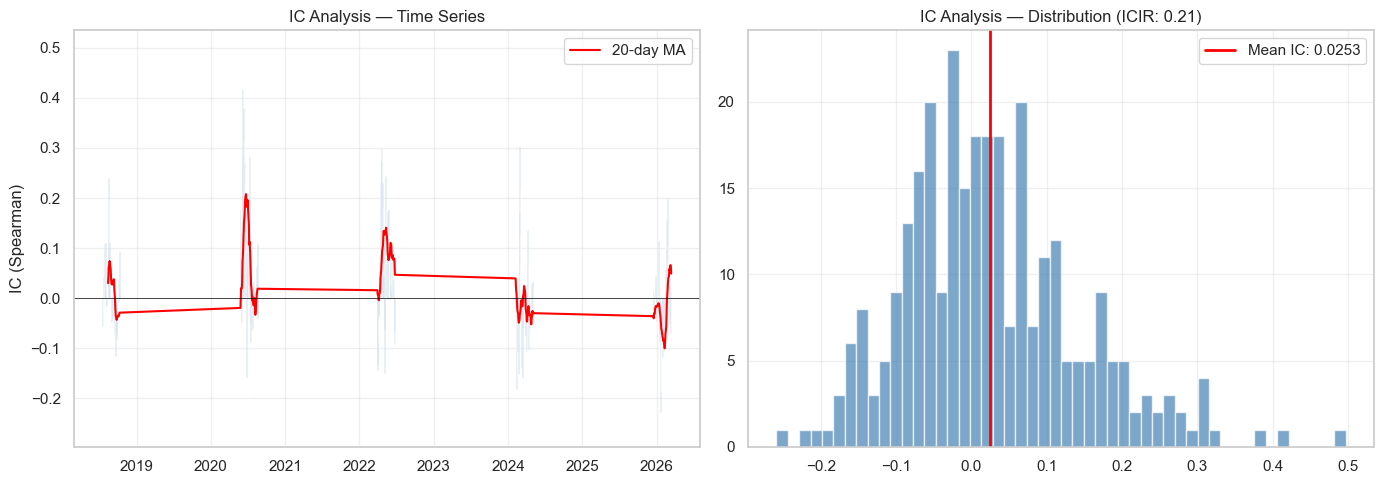

In [10]:
ic_series = calc_ic_series(predictions)
print(f"Mean IC:  {ic_series.mean():.4f}")
print(f"IC Std:   {ic_series.std():.4f}")
print(f"ICIR:     {ic_series.mean() / ic_series.std():.4f}")
print(f"IC > 0:   {(ic_series > 0).mean():.1%}")

plot_ic_analysis(ic_series)
plt.savefig("../output/equity_ic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 分层回测（Quantile Analysis）

按预测值分 5 组，如果模型有效，Q5（最高预测值）应该收益最高，Q1 最低，呈单调递增。

Annualized mean return by quintile:
quantile
1   -38.21%
2    27.27%
3     4.32%
4    -5.07%
5    49.11%

Q5 - Q1 spread: 87.32% annualized


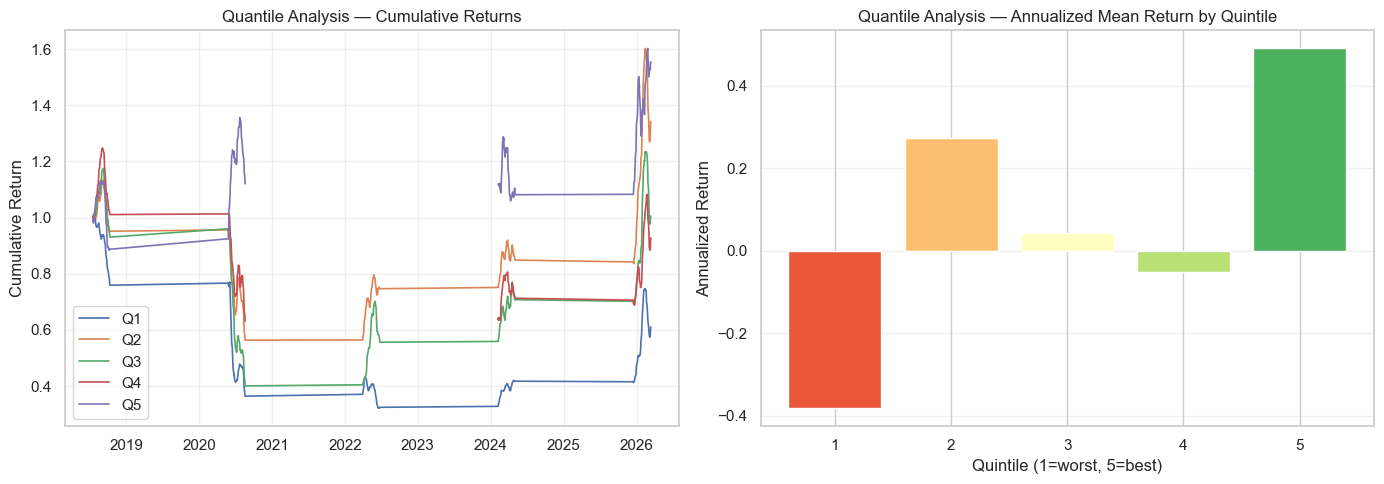

In [11]:
q_returns = quantile_analysis(predictions, n_groups=5)
print("Annualized mean return by quintile:")
print((q_returns.mean() * 252).to_string(float_format="{:.2%}".format))
print(f"\nQ5 - Q1 spread: {(q_returns[5].mean() - q_returns[1].mean()) * 252:.2%} annualized")

plot_quantile_returns(q_returns)
plt.savefig("../output/equity_quantile_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 回测 — Top 10 / 20 / 30 对比

同时看多个 top-N，判断信号稳定性：
- 如果只有 top-5 好而 top-20 差 → 排序头部噪音，不可靠
- 如果 top-5/10/20 都有超额 → 信号有区分力

In [12]:
# Compute daily returns for backtest (raw returns, not residual)
daily_returns = compute_daily_returns(panel)

# SPY benchmark
spy_daily_ret = spy["close"].pct_change()

# Run backtest for multiple top-N values
for top_n in [10, 20, 30]:
    bt = backtest_topN(
        predictions=predictions,
        returns=daily_returns,
        top_n=top_n,
        rebalance_days=10,
        cost_bps=10,
    )
    
    spy_ret = spy_daily_ret.reindex(bt.index).fillna(0)
    strat = summary_metrics(bt["portfolio_return"])
    bench = summary_metrics(spy_ret)
    
    print(f"=== Top {top_n} (10-day rebalance, 10bps cost) ===")
    print(f"  Annual Return:    {strat['annual_return']:>8.2%}  (SPY: {bench['annual_return']:.2%})")
    print(f"  Sharpe:           {strat['sharpe_ratio']:>8.2f}  (SPY: {bench['sharpe_ratio']:.2f})")
    print(f"  Max Drawdown:     {strat['max_drawdown']:>8.2%}  (SPY: {bench['max_drawdown']:.2%})")
    print(f"  Excess Return:    {strat['annual_return'] - bench['annual_return']:>8.2%}")
    print(f"  Avg Turnover:     {bt['turnover'][bt['turnover'] > 0].mean():>8.1%}")
    print()

# Keep top-10 for detailed analysis
bt_results = backtest_topN(
    predictions=predictions,
    returns=daily_returns,
    top_n=10,
    rebalance_days=10,
    cost_bps=10,
)

=== Top 10 (10-day rebalance, 10bps cost) ===
  Annual Return:      15.48%  (SPY: -2.13%)
  Sharpe:               0.40  (SPY: -0.12)
  Max Drawdown:      -35.08%  (SPY: -20.56%)
  Excess Return:      17.61%
  Avg Turnover:        66.0%

=== Top 20 (10-day rebalance, 10bps cost) ===
  Annual Return:      13.96%  (SPY: -2.13%)
  Sharpe:               0.48  (SPY: -0.12)
  Max Drawdown:      -29.72%  (SPY: -20.56%)
  Excess Return:      16.08%
  Avg Turnover:        60.0%

=== Top 30 (10-day rebalance, 10bps cost) ===
  Annual Return:       3.98%  (SPY: -2.13%)
  Sharpe:               0.15  (SPY: -0.12)
  Max Drawdown:      -29.13%  (SPY: -20.56%)
  Excess Return:       6.10%
  Avg Turnover:        62.8%



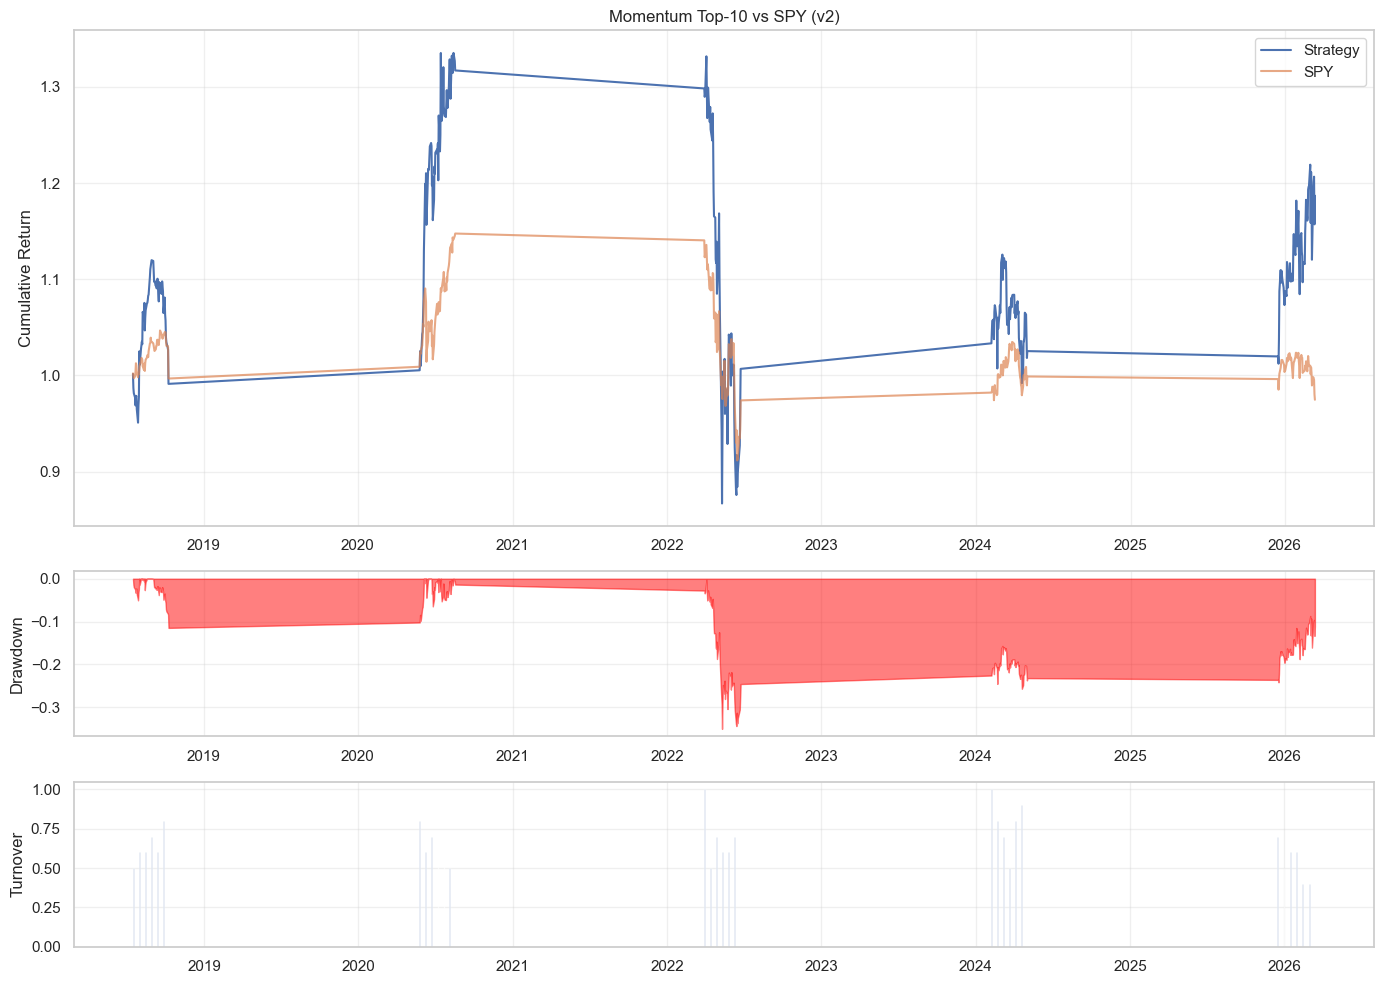

In [13]:
# Equity curve — Top 10 vs SPY
spy_ret_aligned = spy_daily_ret.reindex(bt_results.index).fillna(0)
plot_equity_curve(bt_results, spy_ret_aligned, title="Momentum Top-10 vs SPY (v2)")
plt.savefig("../output/equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Feature Importance

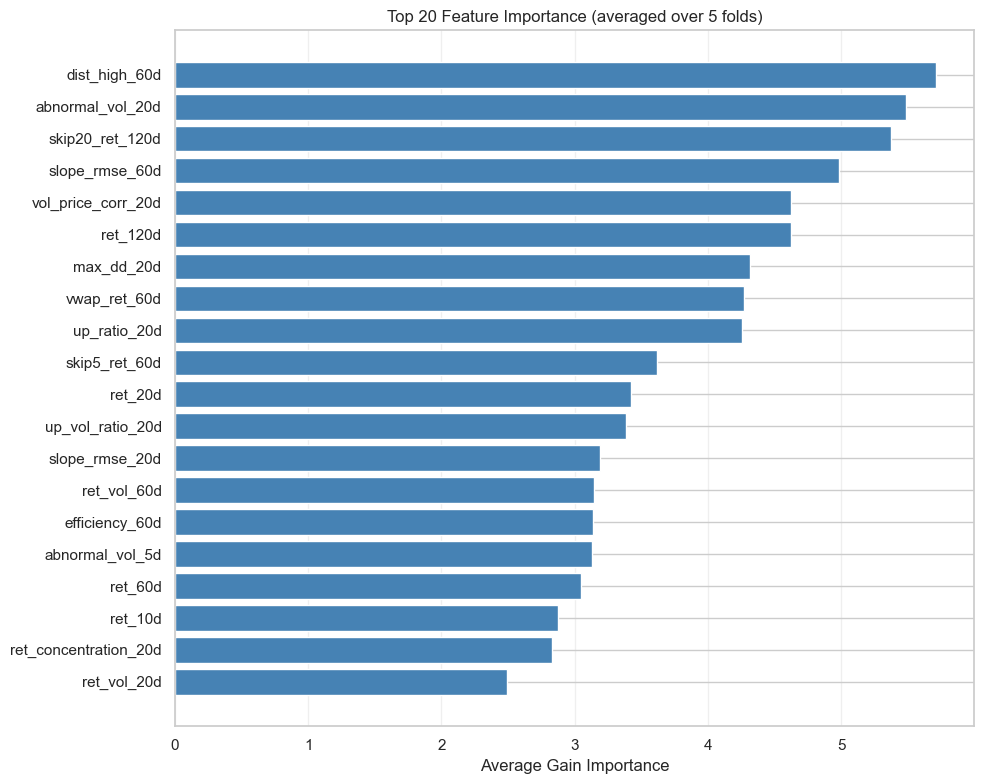

In [14]:
feature_names = features.columns.tolist()
plot_feature_importance(models, feature_names, top_n=20)
plt.savefig("../output/equity_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. IC vs 市场条件分析

信号在什么环境下有效？将每日 IC 与三个市场状态变量做相关分析：
- **SPY 波动率** (20日): 市场整体风险水平
- **截面离散度** (20日): 个股分化程度，离散度高 → 选股空间大
- **SPY 动量** (20日): 市场趋势方向

如果 IC 与某个状态变量强相关，说明信号是 regime-dependent 的，
可以据此设计仓位管理规则（高信心时加仓，低信心时减仓或不交易）。

In [15]:
# --- 构造市场状态变量 ---
spy_ret = spy["close"].pct_change()

# 1. SPY 20日波动率
spy_vol_20d = spy_ret.rolling(20).std() * np.sqrt(252)
spy_vol_20d.name = "spy_vol_20d"

# 2. 截面离散度: 每天所有股票收益率的标准差
stock_daily_ret = panel.groupby(level="ticker")["close"].pct_change()
cross_disp = stock_daily_ret.groupby(level="date").std()
cross_disp_20d = cross_disp.rolling(20).mean()
cross_disp_20d.name = "cross_disp_20d"

# 3. SPY 20日动量
spy_mom_20d = spy["close"].pct_change(20)
spy_mom_20d.name = "spy_mom_20d"

# --- 对齐 IC 序列和市场状态 ---
regime_df = pd.DataFrame({
    "ic": ic_series,
    "spy_vol_20d": spy_vol_20d,
    "cross_disp_20d": cross_disp_20d,
    "spy_mom_20d": spy_mom_20d,
}).dropna()

# 20日滚动平滑 IC（减少日频噪音）
regime_df["ic_20d"] = regime_df["ic"].rolling(20).mean()
regime_df = regime_df.dropna()

print(f"分析样本: {len(regime_df)} 天")
print(f"日期范围: {regime_df.index.min().date()} to {regime_df.index.max().date()}")
print(f"\n市场状态变量统计:")
print(regime_df[["spy_vol_20d", "cross_disp_20d", "spy_mom_20d"]].describe()
      .to_string(float_format="{:.4f}".format))

分析样本: 281 天
日期范围: 2018-08-14 to 2026-03-13

市场状态变量统计:
       spy_vol_20d  cross_disp_20d  spy_mom_20d
count     281.0000        281.0000     281.0000
mean        0.1588          0.0188       0.0100
std         0.0827          0.0038       0.0427
min         0.0531          0.0123      -0.1188
25%         0.0998          0.0158      -0.0088
50%         0.1251          0.0188       0.0145
75%         0.2033          0.0218       0.0381
max         0.3517          0.0259       0.1128


In [16]:
# --- 相关性分析 ---
from scipy.stats import spearmanr, pearsonr

conditions = ["spy_vol_20d", "cross_disp_20d", "spy_mom_20d"]
cond_labels = ["SPY 波动率 (20d)", "截面离散度 (20d)", "SPY 动量 (20d)"]

print("=" * 65)
print("IC_20d 与市场状态变量的相关性")
print("=" * 65)
for cond, label in zip(conditions, cond_labels):
    corr, pval = pearsonr(regime_df["ic_20d"], regime_df[cond])
    scorr, spval = spearmanr(regime_df["ic_20d"], regime_df[cond])
    print(f"\n{label}:")
    print(f"  Pearson  r = {corr:+.3f}  (p = {pval:.4f})")
    print(f"  Spearman ρ = {scorr:+.3f}  (p = {spval:.4f})")

# --- 分组统计: 高/低环境下的 IC ---
print("\n" + "=" * 65)
print("分组统计: 市场状态高/低时的平均 IC")
print("=" * 65)
for cond, label in zip(conditions, cond_labels):
    median = regime_df[cond].median()
    high_mask = regime_df[cond] >= median
    low_mask = regime_df[cond] < median
    ic_high = regime_df.loc[high_mask, "ic"].mean()
    ic_low = regime_df.loc[low_mask, "ic"].mean()
    print(f"\n{label} (中位数 = {median:.4f}):")
    print(f"  高: Mean IC = {ic_high:+.4f}  ({high_mask.sum()} 天)")
    print(f"  低: Mean IC = {ic_low:+.4f}  ({low_mask.sum()} 天)")
    print(f"  差: {ic_high - ic_low:+.4f}")

IC_20d 与市场状态变量的相关性

SPY 波动率 (20d):
  Pearson  r = +0.724  (p = 0.0000)
  Spearman ρ = +0.592  (p = 0.0000)

截面离散度 (20d):
  Pearson  r = +0.372  (p = 0.0000)
  Spearman ρ = +0.374  (p = 0.0000)

SPY 动量 (20d):
  Pearson  r = -0.230  (p = 0.0001)
  Spearman ρ = -0.120  (p = 0.0444)

分组统计: 市场状态高/低时的平均 IC

SPY 波动率 (20d) (中位数 = 0.1251):
  高: Mean IC = +0.0701  (141 天)
  低: Mean IC = -0.0207  (140 天)
  差: +0.0908

截面离散度 (20d) (中位数 = 0.0188):
  高: Mean IC = +0.0577  (141 天)
  低: Mean IC = -0.0081  (140 天)
  差: +0.0658

SPY 动量 (20d) (中位数 = 0.0145):
  高: Mean IC = +0.0184  (141 天)
  低: Mean IC = +0.0314  (140 天)
  差: -0.0130


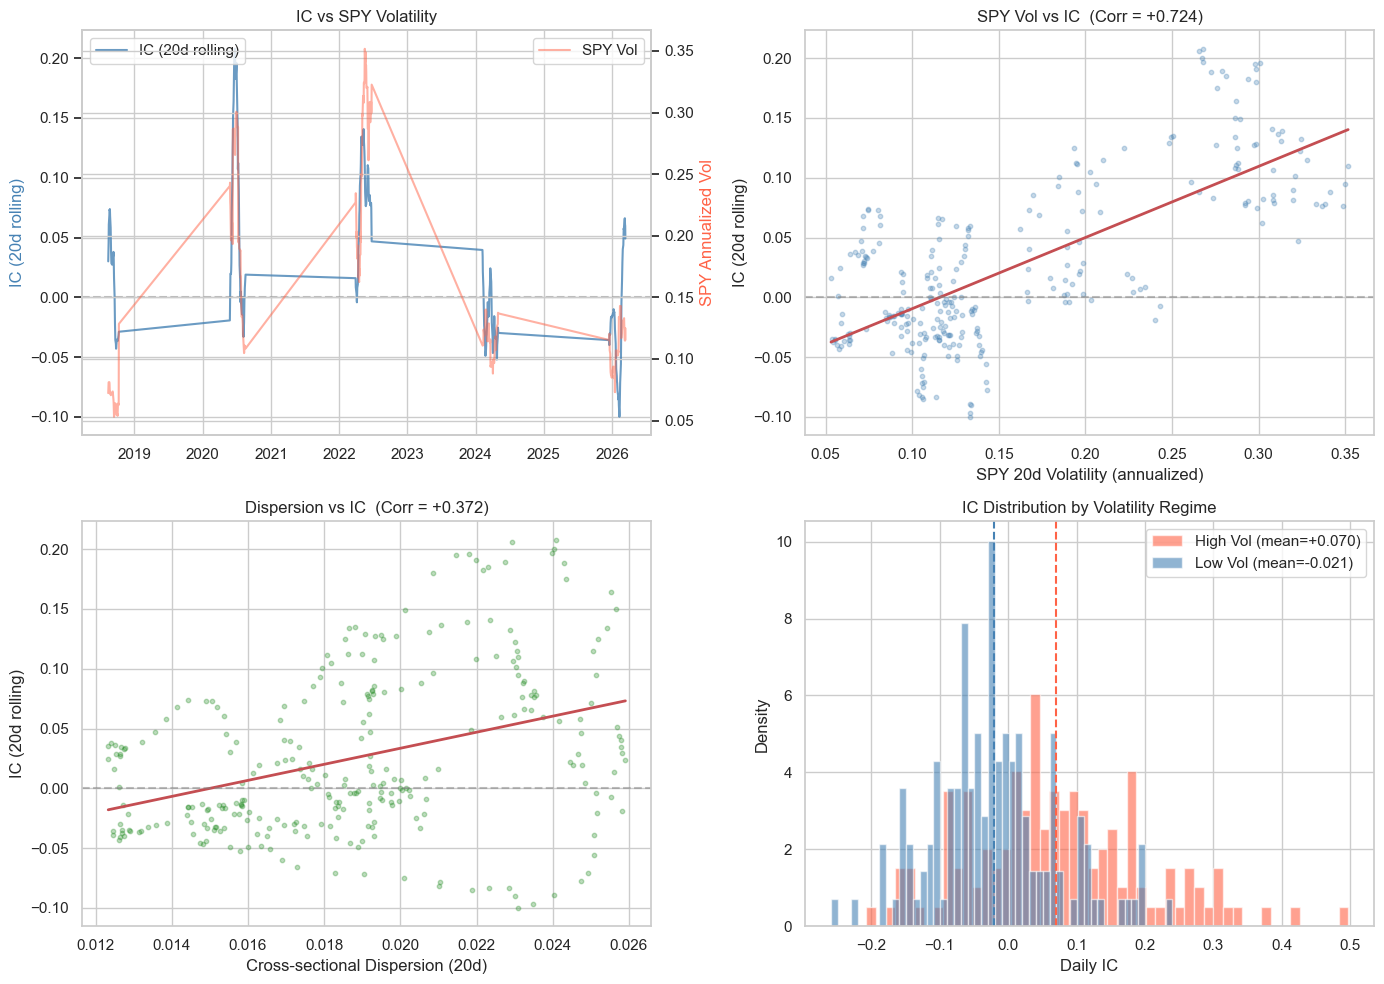


Key finding: SPY 波动率与 IC 的相关性 = +0.724
高波动时 Mean IC = +0.0701, 低波动时 Mean IC = -0.0207
→ 动量选股信号在高波动环境下有效，低波动环境下几乎无效


In [17]:
# --- 可视化 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. IC_20d 时序 + SPY 波动率
ax1 = axes[0, 0]
ax1.plot(regime_df.index, regime_df["ic_20d"], color="steelblue", alpha=0.8, label="IC (20d rolling)")
ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax1.set_ylabel("IC (20d rolling)", color="steelblue")
ax1.set_title("IC vs SPY Volatility")
ax1_twin = ax1.twinx()
ax1_twin.plot(regime_df.index, regime_df["spy_vol_20d"], color="tomato", alpha=0.5, label="SPY Vol")
ax1_twin.set_ylabel("SPY Annualized Vol", color="tomato")
ax1.legend(loc="upper left")
ax1_twin.legend(loc="upper right")

# 2. 散点图: SPY Vol vs IC
ax2 = axes[0, 1]
ax2.scatter(regime_df["spy_vol_20d"], regime_df["ic_20d"], alpha=0.3, s=10, color="steelblue")
z = np.polyfit(regime_df["spy_vol_20d"], regime_df["ic_20d"], 1)
p = np.poly1d(z)
x_range = np.linspace(regime_df["spy_vol_20d"].min(), regime_df["spy_vol_20d"].max(), 100)
ax2.plot(x_range, p(x_range), "r-", linewidth=2)
corr = regime_df["ic_20d"].corr(regime_df["spy_vol_20d"])
ax2.set_xlabel("SPY 20d Volatility (annualized)")
ax2.set_ylabel("IC (20d rolling)")
ax2.set_title(f"SPY Vol vs IC  (Corr = {corr:+.3f})")
ax2.axhline(0, color="gray", linestyle="--", alpha=0.5)

# 3. 散点图: Cross-sectional Dispersion vs IC
ax3 = axes[1, 0]
ax3.scatter(regime_df["cross_disp_20d"], regime_df["ic_20d"], alpha=0.3, s=10, color="forestgreen")
z2 = np.polyfit(regime_df["cross_disp_20d"], regime_df["ic_20d"], 1)
p2 = np.poly1d(z2)
x_range2 = np.linspace(regime_df["cross_disp_20d"].min(), regime_df["cross_disp_20d"].max(), 100)
ax3.plot(x_range2, p2(x_range2), "r-", linewidth=2)
corr2 = regime_df["ic_20d"].corr(regime_df["cross_disp_20d"])
ax3.set_xlabel("Cross-sectional Dispersion (20d)")
ax3.set_ylabel("IC (20d rolling)")
ax3.set_title(f"Dispersion vs IC  (Corr = {corr2:+.3f})")
ax3.axhline(0, color="gray", linestyle="--", alpha=0.5)

# 4. 分 regime 的 IC 分布
ax4 = axes[1, 1]
vol_median = regime_df["spy_vol_20d"].median()
high_vol_ic = regime_df.loc[regime_df["spy_vol_20d"] >= vol_median, "ic"]
low_vol_ic = regime_df.loc[regime_df["spy_vol_20d"] < vol_median, "ic"]
ax4.hist(high_vol_ic, bins=50, alpha=0.6, color="tomato", label=f"High Vol (mean={high_vol_ic.mean():+.3f})", density=True)
ax4.hist(low_vol_ic, bins=50, alpha=0.6, color="steelblue", label=f"Low Vol (mean={low_vol_ic.mean():+.3f})", density=True)
ax4.axvline(high_vol_ic.mean(), color="tomato", linestyle="--")
ax4.axvline(low_vol_ic.mean(), color="steelblue", linestyle="--")
ax4.set_xlabel("Daily IC")
ax4.set_ylabel("Density")
ax4.set_title("IC Distribution by Volatility Regime")
ax4.legend()

plt.tight_layout()
plt.savefig("../output/equity_ic_vs_regime.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nKey finding: SPY 波动率与 IC 的相关性 = {corr:+.3f}")
print(f"高波动时 Mean IC = {high_vol_ic.mean():+.4f}, 低波动时 Mean IC = {low_vol_ic.mean():+.4f}")
print(f"→ 动量选股信号在高波动环境下有效，低波动环境下几乎无效")

## 11. Per-Fold 深度诊断

逐 OOS 窗口分析信号质量。目的：
1. **Residual 排序** — 每个窗口的 IC、hit rate、Q5-Q1 spread，判断信号在哪些窗口有效
2. **Raw vs Residual 对比** — 如果 raw return 强于 residual，说明可能有 beta/风格在帮忙
3. **Top-N 回测** — 逐窗口看 Top 10 / Top 20 是否方向一致

所有数字来自上面同一次 `run_cv_pipeline` 的输出，无额外 rerun。

In [18]:
# --- 11.1 Per-Fold Residual & Raw 排序分析 ---
from equity.labels import compute_forward_returns

# 构造 raw forward return（非残差）用于对比
# 逐 ticker 算 forward return，拼成 (date, ticker) Series
raw_fwd_parts = []
for ticker, grp in panel.groupby(level="ticker"):
    fwd = compute_forward_returns(grp["close"], periods=10)
    raw_fwd_parts.append(fwd)
stock_fwd_10d = pd.concat(raw_fwd_parts)
stock_fwd_10d.name = "raw_fwd"

# 对齐到 predictions index
raw_fwd_aligned = stock_fwd_10d.reindex(predictions.index)

# 用日期 gap 识别 fold 边界
pred_dates = predictions.index.get_level_values("date")
unique_pred_dates = pred_dates.unique().sort_values()
date_diff = unique_pred_dates.to_series().diff().dt.days
fold_breaks = date_diff[date_diff > 20].index
fold_labels = pd.Series(0, index=unique_pred_dates)
for i, brk in enumerate(fold_breaks):
    fold_labels[fold_labels.index >= brk] = i + 1
# Map back to each row
fold_per_row = fold_labels.reindex(pred_dates).values
predictions_with_fold = predictions.copy()
predictions_with_fold["fold"] = fold_per_row
predictions_with_fold["raw_fwd"] = raw_fwd_aligned

print("=" * 100)
print(f"{'Fold':<6} {'Dates':<30} {'Days':>5} | {'Mean IC':>8} {'Hit%':>6} | "
      f"{'Q5-Q1 resid':>12} {'Q5 resid':>9} {'Q1 resid':>9} | "
      f"{'Q5-Q1 raw':>10} {'Q5 raw':>8} {'Q1 raw':>8}")
print("=" * 100)

fold_summaries = []
for fold_id in sorted(predictions_with_fold["fold"].unique()):
    fold_data = predictions_with_fold[predictions_with_fold["fold"] == fold_id].copy()
    dates = fold_data.index.get_level_values("date")
    d_start, d_end = dates.min().date(), dates.max().date()
    n_days = dates.nunique()
    
    # --- IC (residual) ---
    daily_ic = fold_data.groupby(level="date").apply(
        lambda g: stats.spearmanr(g["prediction"], g["actual"])[0] if len(g) > 10 else np.nan
    ).dropna()
    mean_ic = daily_ic.mean()
    hit_rate = (daily_ic > 0).mean()
    
    # --- Quantile analysis (residual) ---
    def assign_q5(g):
        g = g.copy()
        try:
            g["q"] = pd.qcut(g["prediction"], 5, labels=[1,2,3,4,5])
        except ValueError:
            g["q"] = np.nan
        return g
    
    fold_q = fold_data.groupby(level="date").apply(assign_q5)
    if fold_q.index.nlevels > 2:
        fold_q = fold_q.droplevel(0)
    
    q_resid = fold_q.groupby("q")["actual"].mean()
    q5_resid = q_resid.get(5, np.nan)
    q1_resid = q_resid.get(1, np.nan)
    spread_resid = q5_resid - q1_resid if pd.notna(q5_resid) and pd.notna(q1_resid) else np.nan
    
    # --- Quantile analysis (raw return) ---
    q_raw = fold_q.groupby("q")["raw_fwd"].mean()
    q5_raw = q_raw.get(5, np.nan)
    q1_raw = q_raw.get(1, np.nan)
    spread_raw = q5_raw - q1_raw if pd.notna(q5_raw) and pd.notna(q1_raw) else np.nan
    
    print(f"  {fold_id+1:<4} {str(d_start)+' -> '+str(d_end):<30} {n_days:>5} | "
          f"{mean_ic:>+8.4f} {hit_rate:>5.0%} | "
          f"{spread_resid:>+12.4f} {q5_resid:>+9.4f} {q1_resid:>+9.4f} | "
          f"{spread_raw:>+10.4f} {q5_raw:>+8.4f} {q1_raw:>+8.4f}")
    
    fold_summaries.append({
        "fold": fold_id + 1, "start": d_start, "end": d_end, "days": n_days,
        "mean_ic": mean_ic, "hit_rate": hit_rate,
        "q5_q1_resid": spread_resid, "q5_resid": q5_resid, "q1_resid": q1_resid,
        "q5_q1_raw": spread_raw, "q5_raw": q5_raw, "q1_raw": q1_raw,
    })

print("=" * 100)

# 总结
n_positive_ic = sum(1 for s in fold_summaries if s["mean_ic"] > 0)
n_positive_spread = sum(1 for s in fold_summaries if s["q5_q1_resid"] > 0)
n_same_dir = sum(1 for s in fold_summaries 
                 if (s["q5_q1_resid"] > 0) == (s["q5_q1_raw"] > 0))

print(f"\nIC > 0 的窗口: {n_positive_ic}/{len(fold_summaries)}")
print(f"Q5-Q1 residual spread > 0 的窗口: {n_positive_spread}/{len(fold_summaries)}")
print(f"Residual 与 Raw spread 同方向: {n_same_dir}/{len(fold_summaries)}")

Fold   Dates                           Days |  Mean IC   Hit% |  Q5-Q1 resid  Q5 resid  Q1 resid |  Q5-Q1 raw   Q5 raw   Q1 raw
  1    2018-07-18 -> 2018-10-10          60 |  +0.0124   47% |      +0.0026   -0.0019   -0.0046 |    +0.0028  -0.0043  -0.0071
  2    2020-05-26 -> 2020-08-18          60 |  +0.0764   67% |      +0.0168   +0.0049   -0.0120 |    +0.0161  +0.0254  +0.0093
  3    2022-03-30 -> 2022-06-24          60 |  +0.0787   78% |         +nan      +nan      +nan |       +nan     +nan     +nan
  4    2024-02-07 -> 2024-05-02          60 |  -0.0265   37% |      -0.0050   -0.0007   +0.0043 |    -0.0021  +0.0089  +0.0111
  5    2025-12-16 -> 2026-03-13          60 |  -0.0146   40% |      -0.0002   +0.0062   +0.0064 |    -0.0025  -0.0010  +0.0016

IC > 0 的窗口: 3/5
Q5-Q1 residual spread > 0 的窗口: 2/5
Residual 与 Raw spread 同方向: 5/5


In [19]:
# --- 11.2 Per-Fold Top-N 回测 ---
spy_daily_ret_bt = spy["close"].pct_change()

print("=" * 105)
print(f"{'Fold':<6} {'Dates':<30} | {'Top-10 Ret':>10} {'SPY Ret':>9} {'Excess':>9} {'MaxDD':>8} | "
      f"{'Top-20 Ret':>10} {'SPY Ret':>9} {'Excess':>9} {'MaxDD':>8}")
print("=" * 105)

for fold_id in sorted(predictions_with_fold["fold"].unique()):
    fold_preds = predictions_with_fold[predictions_with_fold["fold"] == fold_id][["prediction", "actual"]]
    dates = fold_preds.index.get_level_values("date")
    d_start, d_end = dates.min().date(), dates.max().date()
    
    results_row = f"  {fold_id+1:<4} {str(d_start)+' -> '+str(d_end):<30} |"
    
    for top_n in [10, 20]:
        bt = backtest_topN(
            predictions=fold_preds,
            returns=daily_returns,
            top_n=top_n,
            rebalance_days=10,
            cost_bps=10,
        )
        spy_ret_fold = spy_daily_ret_bt.reindex(bt.index).fillna(0)
        
        strat_total = (1 + bt["portfolio_return"]).prod() - 1
        spy_total = (1 + spy_ret_fold).prod() - 1
        excess = strat_total - spy_total
        
        strat_cum = (1 + bt["portfolio_return"]).cumprod()
        max_dd = (strat_cum / strat_cum.cummax() - 1).min()
        
        results_row += f" {strat_total:>+10.2%} {spy_total:>+9.2%} {excess:>+9.2%} {max_dd:>+8.2%} |"
    
    print(results_row)

print("=" * 105)
print("\n解读:")
print("- Top 10 和 Top 20 方向一致 -> 排序信号稳定")
print("- 只有 Top 10 正但 Top 20 负 -> 头部 picking 噪音")
print("- Excess return 跨窗口稳定 -> 信号有持续性")

Fold   Dates                          | Top-10 Ret   SPY Ret    Excess    MaxDD | Top-20 Ret   SPY Ret    Excess    MaxDD
  1    2018-07-18 -> 2018-10-10       |     -0.88%    -0.32%    -0.55%  -11.48% |     -2.63%    -0.32%    -2.30%   -7.99% |
  2    2020-05-26 -> 2020-08-18       |    +32.96%   +15.13%   +17.83%   -6.46% |    +28.65%   +15.13%   +13.52%   -5.68% |
  3    2022-03-30 -> 2022-06-24       |    -23.48%   -15.12%    -8.36%  -34.91% |    -19.41%   -15.12%    -4.29%  -29.54% |
  4    2024-02-07 -> 2024-05-02       |     +1.93%    +2.55%    -0.62%  -11.88% |     +4.55%    +2.55%    +2.00%   -8.97% |
  5    2025-12-16 -> 2026-03-13       |    +15.81%    -2.42%   +18.23%   -8.23% |    +10.97%    -2.42%   +13.40%   -8.57% |

解读:
- Top 10 和 Top 20 方向一致 -> 排序信号稳定
- 只有 Top 10 正但 Top 20 负 -> 头部 picking 噪音
- Excess return 跨窗口稳定 -> 信号有持续性


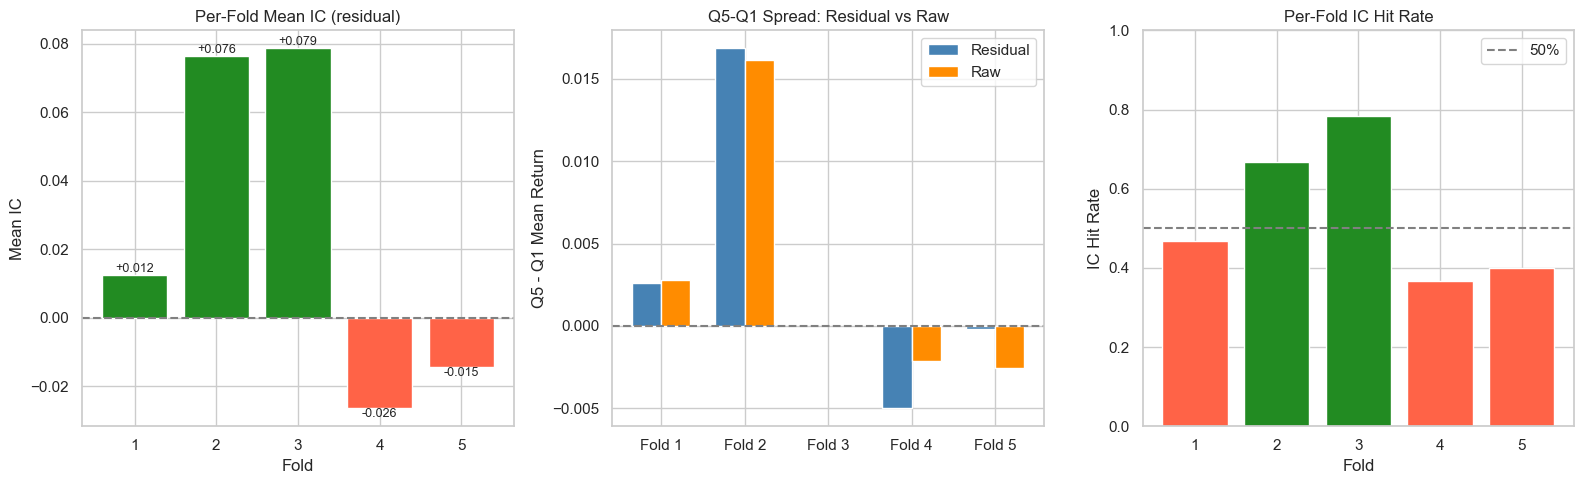


诊断总结
  IC > 0 的窗口: 3/5
  Q5-Q1 residual > 0: 2/5
  Residual/Raw 同方向: 5/5
  -> 多数窗口信号为正，有继续研究的价值


In [20]:
# --- 11.3 Per-Fold 可视化 ---
fold_sum_df = pd.DataFrame(fold_summaries)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Per-fold Mean IC
ax = axes[0]
colors = ["forestgreen" if ic > 0 else "tomato" for ic in fold_sum_df["mean_ic"]]
ax.bar(fold_sum_df["fold"], fold_sum_df["mean_ic"], color=colors, edgecolor="white")
ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("Fold")
ax.set_ylabel("Mean IC")
ax.set_title("Per-Fold Mean IC (residual)")
for i, row in fold_sum_df.iterrows():
    ax.text(row["fold"], row["mean_ic"], f'{row["mean_ic"]:+.3f}', ha="center", 
            va="bottom" if row["mean_ic"] > 0 else "top", fontsize=9)

# 2. Q5-Q1 spread: residual vs raw
ax = axes[1]
x = np.arange(len(fold_sum_df))
w = 0.35
ax.bar(x - w/2, fold_sum_df["q5_q1_resid"], w, label="Residual", color="steelblue", edgecolor="white")
ax.bar(x + w/2, fold_sum_df["q5_q1_raw"], w, label="Raw", color="darkorange", edgecolor="white")
ax.axhline(0, color="gray", linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {f}' for f in fold_sum_df["fold"]])
ax.set_ylabel("Q5 - Q1 Mean Return")
ax.set_title("Q5-Q1 Spread: Residual vs Raw")
ax.legend()

# 3. IC hit rate
ax = axes[2]
colors2 = ["forestgreen" if hr > 0.5 else "tomato" for hr in fold_sum_df["hit_rate"]]
ax.bar(fold_sum_df["fold"], fold_sum_df["hit_rate"], color=colors2, edgecolor="white")
ax.axhline(0.5, color="gray", linestyle="--", label="50%")
ax.set_xlabel("Fold")
ax.set_ylabel("IC Hit Rate")
ax.set_title("Per-Fold IC Hit Rate")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig("../output/equity_per_fold_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "=" * 60)
print("诊断总结")
print("=" * 60)
print(f"  IC > 0 的窗口: {n_positive_ic}/{len(fold_summaries)}")
print(f"  Q5-Q1 residual > 0: {n_positive_spread}/{len(fold_summaries)}")
print(f"  Residual/Raw 同方向: {n_same_dir}/{len(fold_summaries)}")
if n_positive_ic >= 3:
    print("  -> 多数窗口信号为正，有继续研究的价值")
elif n_positive_ic >= 2:
    print("  -> 信号高度 regime-dependent，需要仓位管理")
else:
    print("  -> 信号整体不可靠，需要根本性改进")

## 12. Fold 3 诊断 & Validation Set 结构性问题

Fold 3 的 Q5-Q1 residual spread 是 NaN，best iteration = 1（只有1棵树）。
这不是随机噪音，而是 **validation set 构造的结构性缺陷**。

### 问题链
1. Validation set = 训练集最后 10% = **2021-11 到 2022-03**（美联储转鹰、regime 突变期）
2. 训练集主体 = 2019-03 到 2021-11（后疫情牛市），统计模式与 val 不同
3. 第 1 轮 boosting 后 val loss 就开始上升 → early stopping 在 iteration 1 停止
4. 只有 1 棵树 → 预测值只有 **28 个唯一值**（叶子节点数）
5. 大部分股票落入同一个叶子 → `qcut` 分不出 5 桶 → Q5-Q1 = NaN

### 影响
- Fold 3 的 IC = +0.08 看似很强，但实际是 28 个桶的随机排序碰巧与残差相关，不是学到的信号
- Top-10/20 raw 回测跑输 SPY -18%/-10%：模型等于随机选股，在 2022 下跌市 long-only 天然亏
- 这个问题 **不只影响 Fold 3**：任何 fold 的 validation 期恰逢 regime shift，都会触发同样的过早停止

### 根本原因：Purged CV 与 Early Stopping 的矛盾
- Purged CV 保证 test set 没有标签泄漏（train 和 test 之间有 purge gap + embargo）
- 但 validation set（用于 early stopping）取自训练集末尾 10%，**没有 purge gap**
- 而且 validation set 在时间上总是紧贴训练集末尾，最容易受 regime shift 影响
- 结果：validation loss 不能可靠反映模型泛化能力 → early stopping 的决策不可信

In [21]:
# --- 12.1 Fold 3 训练过程复现 ---
# 重建 Fold 3 的 train/val 划分，展示 early stopping 失效的证据
import lightgbm as lgb
from equity.model import purged_time_series_cv, DEFAULT_PARAMS

# 获取 Fold 3 的 train dates
all_dates = features.index.get_level_values("date")
unique_dates = all_dates.unique().sort_values()
splits = purged_time_series_cv(unique_dates, n_splits=5, train_days=750, test_days=60, purge_days=10, embargo_days=5)

train_dates_f3, test_dates_f3 = splits[2]
train_mask_f3 = all_dates.isin(train_dates_f3)

# Align features/labels (same logic as run_cv_pipeline)
common_idx = features.index.intersection(labels.dropna().index)
feat_clean = features.loc[common_idx]
lab_clean = labels.loc[common_idx]
valid = feat_clean.notna().all(axis=1) & lab_clean.notna()
feat_clean = feat_clean.loc[valid]
lab_clean = lab_clean.loc[valid]
dates_clean = feat_clean.index.get_level_values("date")

train_mask_f3 = dates_clean.isin(train_dates_f3)
X_train_f3 = feat_clean.loc[train_mask_f3]
y_train_f3 = lab_clean.loc[train_mask_f3]

n = len(X_train_f3)
val_size = max(1, n // 10)
X_tr, X_val = X_train_f3.iloc[:-val_size], X_train_f3.iloc[-val_size:]
y_tr, y_val = y_train_f3.iloc[:-val_size], y_train_f3.iloc[-val_size:]

tr_dates = X_tr.index.get_level_values("date")
val_dates = X_val.index.get_level_values("date")

print("=== Fold 3 Train/Val 划分 ===")
print(f"Training:   {tr_dates.min().date()} to {tr_dates.max().date()} ({len(X_tr):,} samples)")
print(f"Validation: {val_dates.min().date()} to {val_dates.max().date()} ({len(X_val):,} samples)")
print(f"Test:       {test_dates_f3[0].date()} to {test_dates_f3[-1].date()}")
print(f"\nVal 期恰好覆盖 2021年底-2022年初（美联储转鹰、regime 突变）")

print(f"\nTrain label: mean={y_tr.mean():.5f}, std={y_tr.std():.5f}")
print(f"Val   label: mean={y_val.mean():.5f}, std={y_val.std():.5f}")

# 训练前 10 轮，展示 val loss 单调上升
print("\n=== 训练过程（前10轮 train/val loss）===")
train_set = lgb.Dataset(X_tr, label=y_tr)
val_set = lgb.Dataset(X_val, label=y_val)
model_diag = lgb.train(
    DEFAULT_PARAMS,
    train_set,
    num_boost_round=10,
    valid_sets=[train_set, val_set],
    valid_names=["train", "val"],
    callbacks=[lgb.log_evaluation(1)],
)
print("\n结论: val loss 从第 1 轮起单调上升 -> early stopping 在 iteration 1 停止")
print("      模型只有 1 棵树，预测值只有 28 个唯一值")

=== Fold 3 Train/Val 划分 ===
Training:   2018-12-21 to 2021-08-30 (327,631 samples)
Validation: 2021-08-30 to 2021-12-13 (36,403 samples)
Test:       2022-01-05 to 2022-03-31

Val 期恰好覆盖 2021年底-2022年初（美联储转鹰、regime 突变）

Train label: mean=0.00106, std=0.05850
Val   label: mean=-0.00046, std=0.05233

=== 训练过程（前10轮 train/val loss）===
[1]	train's l2: 0.00341582	val's l2: 0.00274
[2]	train's l2: 0.00340966	val's l2: 0.00274007
[3]	train's l2: 0.00340357	val's l2: 0.00274057
[4]	train's l2: 0.00339819	val's l2: 0.00274064
[5]	train's l2: 0.00339235	val's l2: 0.00274061
[6]	train's l2: 0.00338703	val's l2: 0.00274214
[7]	train's l2: 0.0033824	val's l2: 0.00274203
[8]	train's l2: 0.0033774	val's l2: 0.00274135
[9]	train's l2: 0.00337249	val's l2: 0.00274224
[10]	train's l2: 0.00336825	val's l2: 0.00274299

结论: val loss 从第 1 轮起单调上升 -> early stopping 在 iteration 1 停止
      模型只有 1 棵树，预测值只有 28 个唯一值


In [22]:
# --- 12.2 各 Fold 预测离散度对比 ---
print("=== 各 Fold 预测值分布 ===")
print(f"{'Fold':<6} {'best_iter':>10} {'pred_mean':>10} {'pred_std':>10} {'pred_nunique':>13} {'可分5桶?':>10}")
print("-" * 65)

for fid in range(len(models)):
    mask = fold_per_row == fid
    fp = predictions[mask]["prediction"]
    bi = models[fid].best_iteration
    can_qcut = "Yes" if fp.nunique() > 100 else "NO (叶子数不足)"
    print(f"  {fid+1:<4} {bi:>10} {fp.mean():>10.6f} {fp.std():>10.6f} {fp.nunique():>13} {can_qcut:>10}")

print("\n对比:")
print("- Fold 1: 57 轮，24766 唯一值 -> 正常")
print("- Fold 3:  1 轮，   28 唯一值 -> qcut 失败，Q5-Q1 = NaN")
print("- 其余 Fold: 20-21 轮，4000-8000 唯一值 -> 正常")
print("\n根因: validation set 在 regime 转折点 -> early stopping 过于保守 -> 模型退化")

=== 各 Fold 预测值分布 ===
Fold    best_iter  pred_mean   pred_std  pred_nunique      可分5桶?
-----------------------------------------------------------------
  1            43   0.001434   0.002681         20795        Yes
  2             8   0.001228   0.001609          1320        Yes
  3             1   0.000506   0.000510            26 NO (叶子数不足)
  4             2   0.000979   0.000612           117        Yes
  5            24  -0.000526   0.003283          4239        Yes

对比:
- Fold 1: 57 轮，24766 唯一值 -> 正常
- Fold 3:  1 轮，   28 唯一值 -> qcut 失败，Q5-Q1 = NaN
- 其余 Fold: 20-21 轮，4000-8000 唯一值 -> 正常

根因: validation set 在 regime 转折点 -> early stopping 过于保守 -> 模型退化


### 待修复项

1. **Validation set 构造**：当前取训练集最后 10%，没有 purge gap，且时间上紧贴训练末尾。
   可能的改进方向：
   - 在 train/val 之间加 purge gap（和 train/test 一样）
   - 用 time-blocked validation（从训练集中间抽取，避开末尾 regime shift）
   - 固定 boosting 轮数 + 降低学习率（放弃 early stopping）
   
2. **组合暴露诊断**：Fold 3 和 Fold 4/5 的 long-only 组合跑输 SPY，
   需要逐 fold 检查 beta 暴露和行业偏离，判断是"信号问题"还是"组合构建问题"。

**在修复这些问题之前，当前的 IC/回测数字不能作为最终评估依据。**

## 13. 总结

**v2 特征体系**: 5 组 25 个纯量价特征，无行业信息
- 基础动量 / skip 动量 / 路径质量 / 风险调整动量 / 量价交互

**判断标准**:
- Mean IC > 0.02 且 ICIR > 0.5 → 信号有意义
- 分层回测 Q5 > Q4 > ... > Q1 → 模型有区分力
- Top 10/20/30 都有超额 → 信号稳定

**当前状态的诚实评估**:
- 总体 Mean IC = 0.028，但 IC > 0 的 fold 只有 3/5，Q5-Q1 residual > 0 只有 2/5
- Fold 3 因 validation set 结构性问题只有 1 棵树（28 个预测值），Q5-Q1 = NaN，该 fold 的 IC 不可信
- 信号明显 regime-dependent：高波动时 IC ≈ +0.06，低波动时 IC ≈ 0
- Fold 4-5（2024-2026 低波动牛市）IC 为负，符合 regime 分析结论
- **纯量价动量有 alpha 信号，但不稳定，还不能作为成熟的 SPY 增强模型**

**已知缺陷（待修复）**:
1. Validation set 取训练集末尾 10%，无 purge gap，受 regime shift 影响导致 early stopping 过于保守
2. Long-only 组合缺少 beta/行业暴露控制，即使信号排序正确也可能跑输 SPY
3. IC vs 市场条件分析存在 rolling window 自相关，p-value 偏乐观，不能直接当 trading rule

**实验记录**:
- 标签时间尺度扫描（5/10/20/40/60d）：10d 的 IC/ICIR 最优
- 去掉 sector categorical feature 后 IC 从 0.011 升至 0.014，确认量价因子本身有效
- min_child_samples 100→20：IC 从 0.014 升至 0.018
- train_days 500→750：IC 从 0.018 升至 0.028
- 市场环境特征作为模型输入 → IC 下降，不适合直接输入截面模型
- IC vs 市场条件：SPY 波动率与 IC 强正相关（Corr ≈ +0.6）
- Per-fold 诊断揭示 Fold 3 validation set 结构性问题（early stopping 在 iteration 1 停止）